In [1]:
import os
import sys

# Set working directory to project root
os.chdir(r'C:\Users\USER\Desktop\immuniwatch_project')

# Verify required directories exist
dirs = ['data/splits', 'data/labeled', 'data/monitoring']
for d in dirs:
    os.makedirs(d, exist_ok=True)

print(f"Working directory: {os.getcwd()}")
print("All directories verified")

Working directory: C:\Users\USER\Desktop\immuniwatch_project
All directories verified


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")


In [4]:
from huggingface_hub import hf_hub_download

file = hf_hub_download(
    repo_id="AHFIDAILabs/immuniwatch",
    filename="labeled_tweets_only.csv",
    repo_type="dataset"
)

df = pd.read_csv(file)


print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

labeled_tweets_only.csv: 0.00B [00:00, ?B/s]

Shape: (11671, 18)

Columns: ['Tweet_Text', 'Reply_Count', 'Retweet_Count', 'Like_Count', 'View_Count', 'Language', 'Source', 'Username', 'Location', 'year', 'month', 'day', 'hour', 'minute', 'weekday', 'Post_ID', 'ID_Source', 'predicted_label']


In [5]:
df1 = df.copy()

In [7]:
df.head(3)

,Tweet_Text,Reply_Count,Retweet_Count,Like_Count,View_Count,Language,Source,Username,Location,year,month,day,hour,minute,weekday,Post_ID,ID_Source,predicted_label
0,The HPV vaccine is a critical step in preventi...,1.0,0.0,2.0,81.0,English,Twitter,VaccineNet_NG,"Lagos, Nigeria",2024,7,1,17,58,Monday,"=""1807821100576895401""",Platform_ID,Factual
1,Blessing is protected against cervical cancer....,0.0,1.0,6.0,137.0,English,Twitter,VaccineNet_NG,Lagos,2024,6,27,14,27,Thursday,"=""1806318372742635560""",Platform_ID,Factual
2,@science_nigeria @nighealthwatch @Fmohnigeria ...,0.0,0.0,0.0,5.0,English,Twitter,VaccineNet_NG,Nigeria,2024,6,25,11,8,Tuesday,"=""1805543612580606082""",Platform_ID,Factual


In [8]:
print("=== LABEL COLUMN INSPECTION ===")
print(f"Column name: predicted_label")
print(f"\nValue counts:")
print(df['predicted_label'].value_counts())
print(f"\nNull values: {df['predicted_label'].isna().sum()}")
print(f"\nUnique labels: {df['predicted_label'].unique()}")

=== LABEL COLUMN INSPECTION ===
Column name: predicted_label

Value counts:
predicted_label
Uncertain         6464
Factual           4489
Misinformation     718
Name: count, dtype: int64

Null values: 0

Unique labels: ['Factual' 'Uncertain' 'Misinformation']


In [9]:
print("=== STANDARDIZING LABELS ===")

# Standardize label casing
df['predicted_label'] = df['predicted_label'].str.strip().str.capitalize()

# Verify
print("Labels after standardization:")
print(df['predicted_label'].value_counts())
print(f"\nNull values after cleaning: {df['predicted_label'].isna().sum()}")

=== STANDARDIZING LABELS ===
Labels after standardization:
predicted_label
Uncertain         6464
Factual           4489
Misinformation     718
Name: count, dtype: int64

Null values after cleaning: 0


In [10]:
print("=== DROPPING NULL LABELS ===")
before = len(df)
df = df[df['predicted_label'].notna()].reset_index(drop=True)
after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Dropped:     {before - after:,}")
print(f"\nFinal label distribution:")
print(df['predicted_label'].value_counts())

=== DROPPING NULL LABELS ===
Rows before: 11,671
Rows after:  11,671
Dropped:     0

Final label distribution:
predicted_label
Uncertain         6464
Factual           4489
Misinformation     718
Name: count, dtype: int64


In [11]:
print("=== CLASS DISTRIBUTION ===")
counts = df['predicted_label'].value_counts()
total = len(df)

for label, count in counts.items():
    pct = (count / total) * 100
    print(f"  {label:<20} {count:>6,}  ({pct:.1f}%)")

print(f"\nTotal: {total:,}")
print(f"\nClass imbalance ratio: {counts.max() / counts.min():.1f}x")
#print("\nStratified splitting will be applied to preserve this distribution across all splits")

=== CLASS DISTRIBUTION ===
  Uncertain             6,464  (55.4%)
  Factual               4,489  (38.5%)
  Misinformation          718  (6.2%)

Total: 11,671

Class imbalance ratio: 9.0x


In [12]:
print("=== CREATING STRATIFIED SPLITS ===")

# Step 1: Split off test set (15%)
train_val, test = train_test_split(
    df,
    test_size=0.15,
    stratify=df['predicted_label'],
    random_state=42
)

# Step 2: Split remaining into train (70%) and val (15%)
# 0.15 / 0.85 = 0.1765 gives us 15% of total for val
train, val = train_test_split(
    train_val,
    test_size=0.1765,
    stratify=train_val['predicted_label'],
    random_state=42
)

print(f"Train size: {len(train):,}  ({len(train)/total*100:.1f}%)")
print(f"Val size:   {len(val):,}  ({len(val)/total*100:.1f}%)")
print(f"Test size:  {len(test):,}  ({len(test)/total*100:.1f}%)")
print(f"Total:      {len(train) + len(val) + len(test):,}")

=== CREATING STRATIFIED SPLITS ===
Train size: 8,169  (70.0%)
Val size:   1,751  (15.0%)
Test size:  1,751  (15.0%)
Total:      11,671


In [13]:
print("=== LABEL DISTRIBUTION ACROSS SPLITS ===")

splits = {'Train': train, 'Val': val, 'Test': test}

for split_name, split_df in splits.items():
    print(f"\n{split_name}:")
    counts = split_df['predicted_label'].value_counts()
    for label, count in counts.items():
        pct = (count / len(split_df)) * 100
        print(f"  {label:<20} {count:>5,}  ({pct:.1f}%)")

#print("\nDistributions are consistent across splits - stratification successful")

=== LABEL DISTRIBUTION ACROSS SPLITS ===

Train:
  Uncertain            4,524  (55.4%)
  Factual              3,143  (38.5%)
  Misinformation         502  (6.1%)

Val:
  Uncertain              970  (55.4%)
  Factual                673  (38.4%)
  Misinformation         108  (6.2%)

Test:
  Uncertain              970  (55.4%)
  Factual                673  (38.4%)
  Misinformation         108  (6.2%)


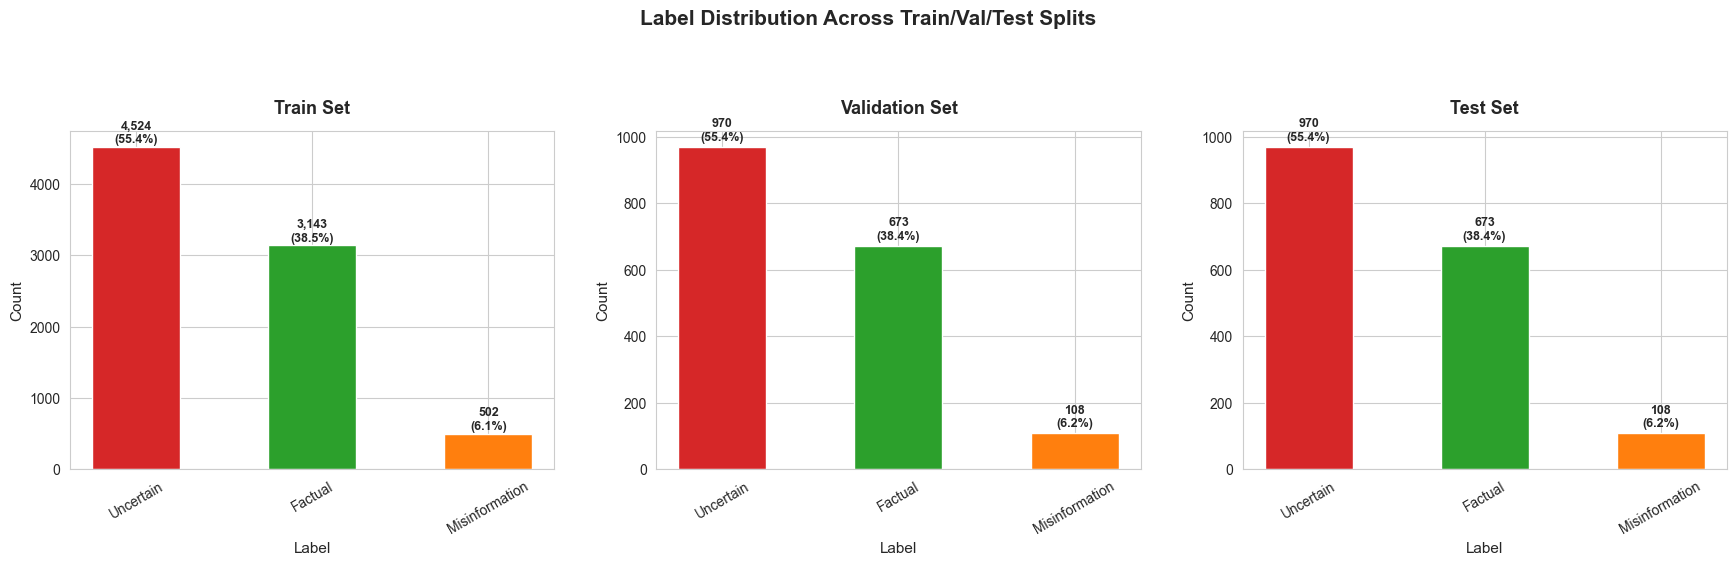

Saved: data/monitoring/split_distribution.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

split_data = [
    (train, 'Train Set'),
    (val, 'Validation Set'),
    (test, 'Test Set')
]

colors = ['#d62728', '#2ca02c', '#ff7f0e']

for idx, (split_df, title) in enumerate(split_data):
    counts = split_df['predicted_label'].value_counts()
    total_split = len(split_df)

    bars = axes[idx].bar(
        counts.index, counts.values,
        color=colors[:len(counts)], width=0.5, edgecolor='white'
    )
    axes[idx].set_title(title, fontsize=13, fontweight='bold', pad=12)
    axes[idx].set_xlabel('Label', fontsize=11)
    axes[idx].set_ylabel('Count', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=30)

    for bar in bars:
        count = int(bar.get_height())
        pct = (count / total_split) * 100
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.suptitle('Label Distribution Across Train/Val/Test Splits',
             fontsize=15, fontweight='bold')
plt.tight_layout(pad=3.0)
plt.savefig('data/monitoring/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/split_distribution.png")

In [15]:
#saving the splits

train.to_csv('data/splits/train.csv', index=False)
val.to_csv('data/splits/val.csv', index=False)
test.to_csv('data/splits/test.csv', index=False)

print(f"Saved: data/splits/train.csv  ({len(train):,} rows)")
print(f"Saved: data/splits/val.csv    ({len(val):,} rows)")
print(f"Saved: data/splits/test.csv   ({len(test):,} rows)")

Saved: data/splits/train.csv  (8,169 rows)
Saved: data/splits/val.csv    (1,751 rows)
Saved: data/splits/test.csv   (1,751 rows)


In [16]:
#print("=== VERIFYING SAVED FILES ===")

for split_name, filename in [('Train', 'train'), ('Val', 'val'), ('Test', 'test')]:
    loaded = pd.read_csv(f'data/splits/{filename}.csv')
    print(f"{split_name}: {len(loaded):,} rows | "
          f"Columns: {loaded.shape[1]} | "
          f"Labels: {loaded['predicted_label'].value_counts().to_dict()}")

Train: 8,169 rows | Columns: 18 | Labels: {'Uncertain': 4524, 'Factual': 3143, 'Misinformation': 502}
Val: 1,751 rows | Columns: 18 | Labels: {'Uncertain': 970, 'Factual': 673, 'Misinformation': 108}
Test: 1,751 rows | Columns: 18 | Labels: {'Uncertain': 970, 'Factual': 673, 'Misinformation': 108}


In [18]:
print("=== COMPUTING CLASS WEIGHTS FOR COST-SENSITIVE LEARNING ===")
from sklearn.utils.class_weight import compute_class_weight

# Label encoding
label2id = {'Misinformation': 0, 'Factual': 1, 'Uncertain': 2}
id2label = {0: 'Misinformation', 1: 'Factual', 2: 'Uncertain'}

train_labels = train['predicted_label'].map(label2id).values

classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)

class_weights = {id2label[i]: round(weights[i], 4) for i in range(len(weights))}
print("Class weights for cost-sensitive learning:")
for label, weight in class_weights.items():
    print(f"  {label:<20} {weight}")

#print("\nHigher weight = model penalized more for misclassifying this class")
#print("Misinformation will have the highest weight due to class imbalance")

# Save for use in notebook 03
import json
weight_dict = {str(i): weights[i] for i in range(len(weights))}
with open('data/splits/class_weights.json', 'w') as f:
    json.dump(weight_dict, f, indent=2)

print("\nSaved: data/splits/class_weights.json")

=== COMPUTING CLASS WEIGHTS FOR COST-SENSITIVE LEARNING ===
Class weights for cost-sensitive learning:
  Misinformation       5.4243
  Factual              0.8664
  Uncertain            0.6019

Saved: data/splits/class_weights.json
